# VARiance Bias Trade off

Bias_variance_trade_off is technique is to find and balancing the true relationship between the low bias data and the new data to not to act senestively to noise

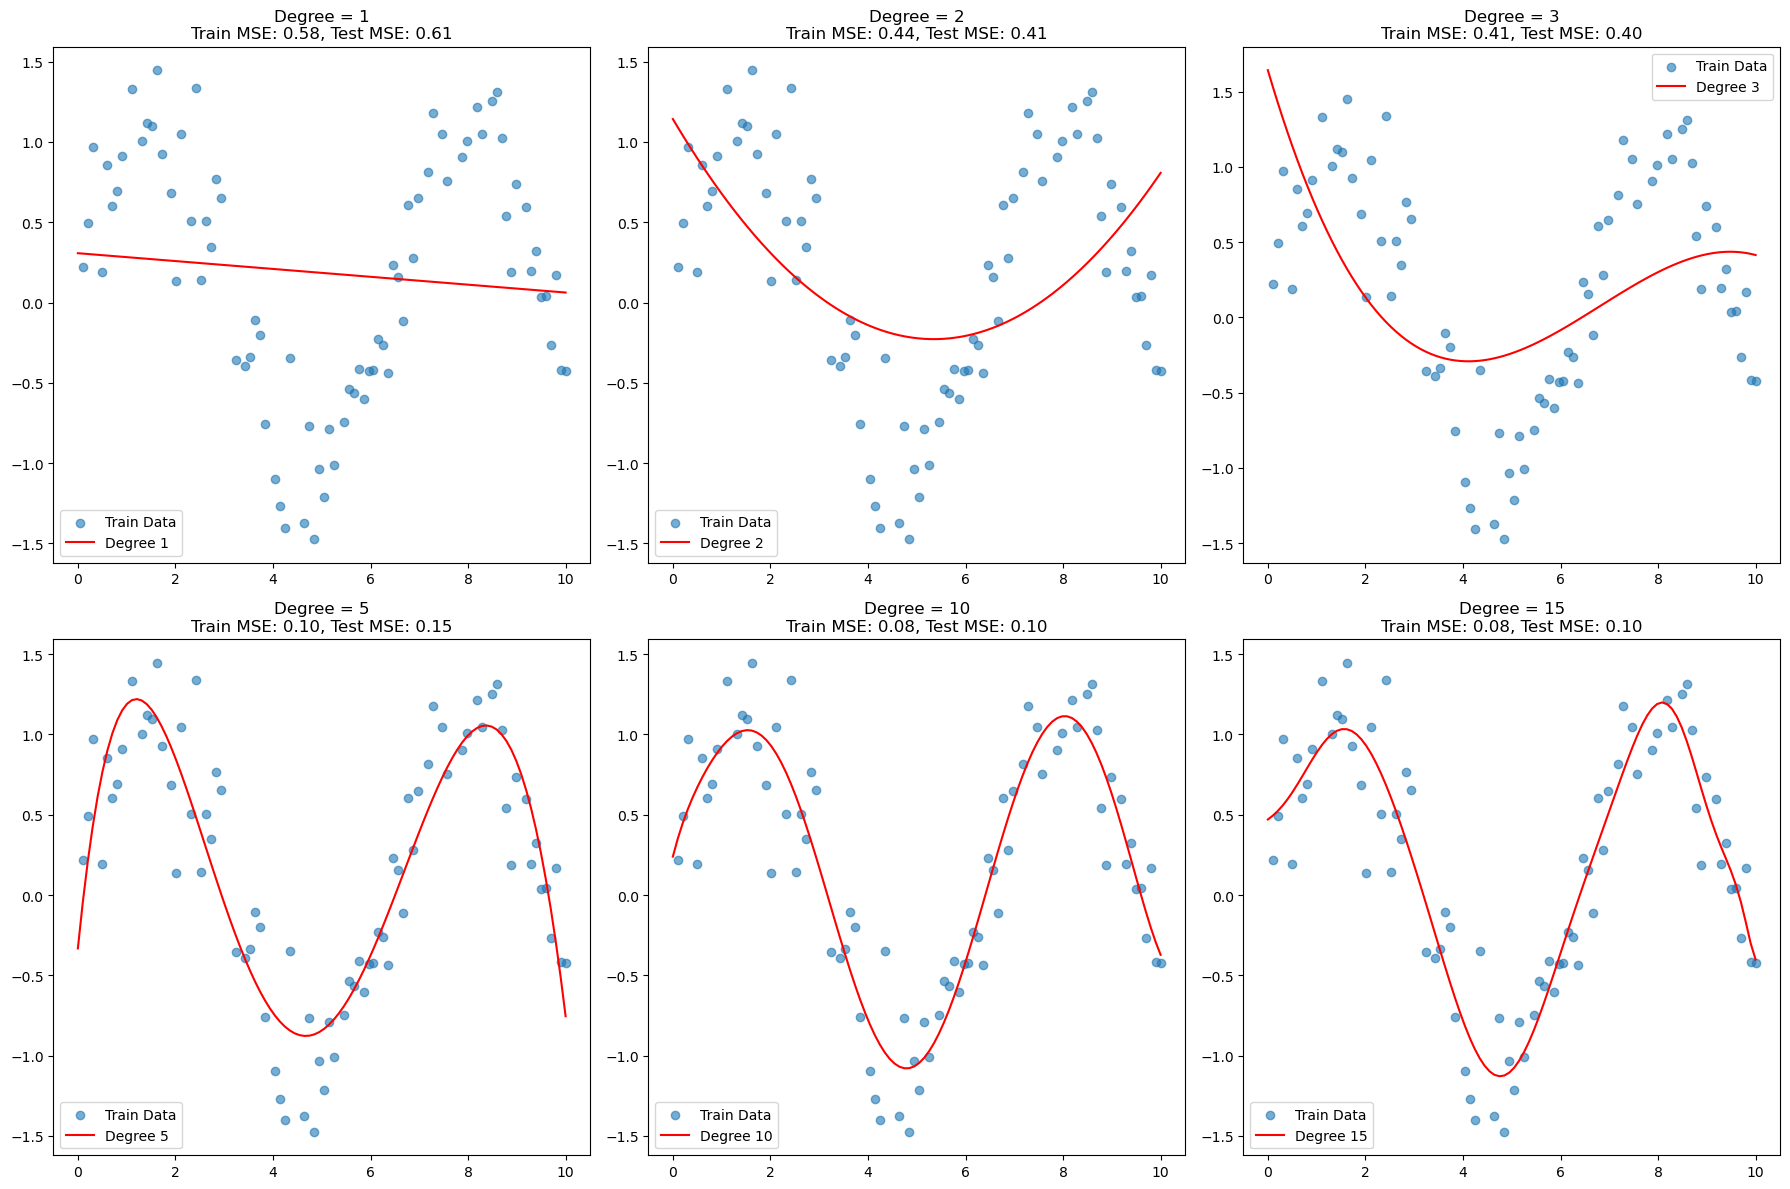

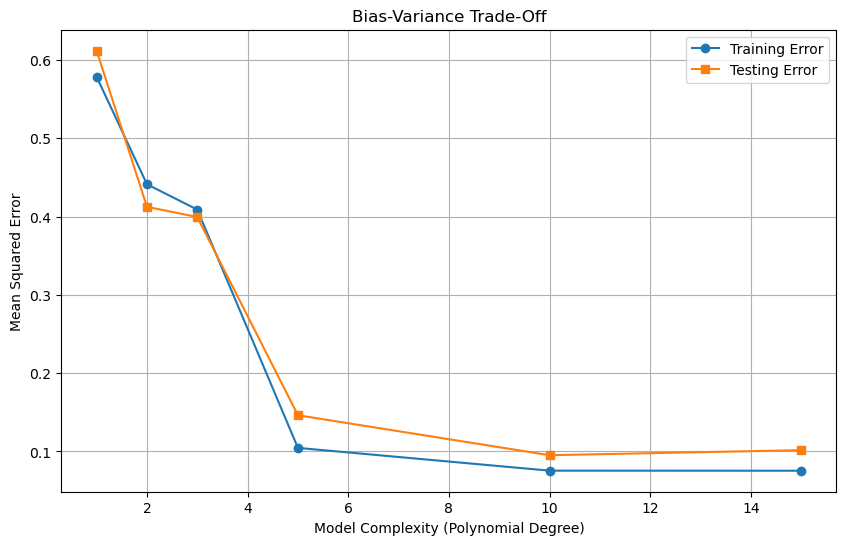

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Generate synthetic non-linear data
np.random.seed(0)
x = np.linspace(0, 10, 100)
y = np.sin(x) + np.random.randn(100) * 0.3  # True function with noise

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

# Split into training and testing datasets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Lists to store training and testing errors
train_errors = []
test_errors = []
degrees = [1, 2, 3, 5, 10, 15]

plt.figure(figsize=(18, 12))

for i, degree in enumerate(degrees, 1):
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)

    # Fit linear regression model
    model = LinearRegression()
    model.fit(x_train_poly, y_train)

    # Predict on training and testing data
    y_train_pred = model.predict(x_train_poly)
    y_test_pred = model.predict(x_test_poly)

    # Calculate Mean Squared Error
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_errors.append(train_mse)
    test_errors.append(test_mse)

    # Plot the model's predictions
    x_curve = np.linspace(0, 10, 100).reshape(-1, 1)
    x_curve_poly = poly.transform(x_curve)
    y_curve = model.predict(x_curve_poly)

    plt.subplot(2, 3, i)
    plt.scatter(x_train, y_train, label='Train Data', alpha=0.6)
    plt.plot(x_curve, y_curve, color='red', label=f'Degree {degree}')
    plt.title(f'Degree = {degree}\nTrain MSE: {train_mse:.2f}, Test MSE: {test_mse:.2f}')
    plt.legend()

plt.tight_layout()
plt.show()

# Plot training and testing errors
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, marker='o', label='Training Error')
plt.plot(degrees, test_errors, marker='s', label='Testing Error')
plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Mean Squared Error")
plt.title("Bias-Variance Trade-Off")
plt.legend()
plt.grid(True)
plt.show()


In [3]:
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [6]:
np.logspace(-5, 2 ,10)

array([1.00000000e-05, 5.99484250e-05, 3.59381366e-04, 2.15443469e-03,
       1.29154967e-02, 7.74263683e-02, 4.64158883e-01, 2.78255940e+00,
       1.66810054e+01, 1.00000000e+02])

In [7]:
import numpy as np
from sklearn.model_selection import validation_curve
from sklearn.datasets import load_iris
from sklearn.linear_model import Ridge

In [8]:
iris = load_iris(as_frame=True)

In [9]:
X , y = iris.data, iris.target

In [10]:
X


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [11]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int32

In [14]:
indices = np.arange(y.shape[0])
np.random.shuffle(indices)
X = X.iloc[indices]
y = y.iloc[indices]



In [15]:
X


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
98,5.1,2.5,3.0,1.1
96,5.7,2.9,4.2,1.3
149,5.9,3.0,5.1,1.8
144,6.7,3.3,5.7,2.5
15,5.7,4.4,1.5,0.4
...,...,...,...,...
22,4.6,3.6,1.0,0.2
68,6.2,2.2,4.5,1.5
20,5.4,3.4,1.7,0.2
28,5.2,3.4,1.4,0.2


In [16]:
param_name = 'alpha'
param_range = np.logspace(-5,2,10)

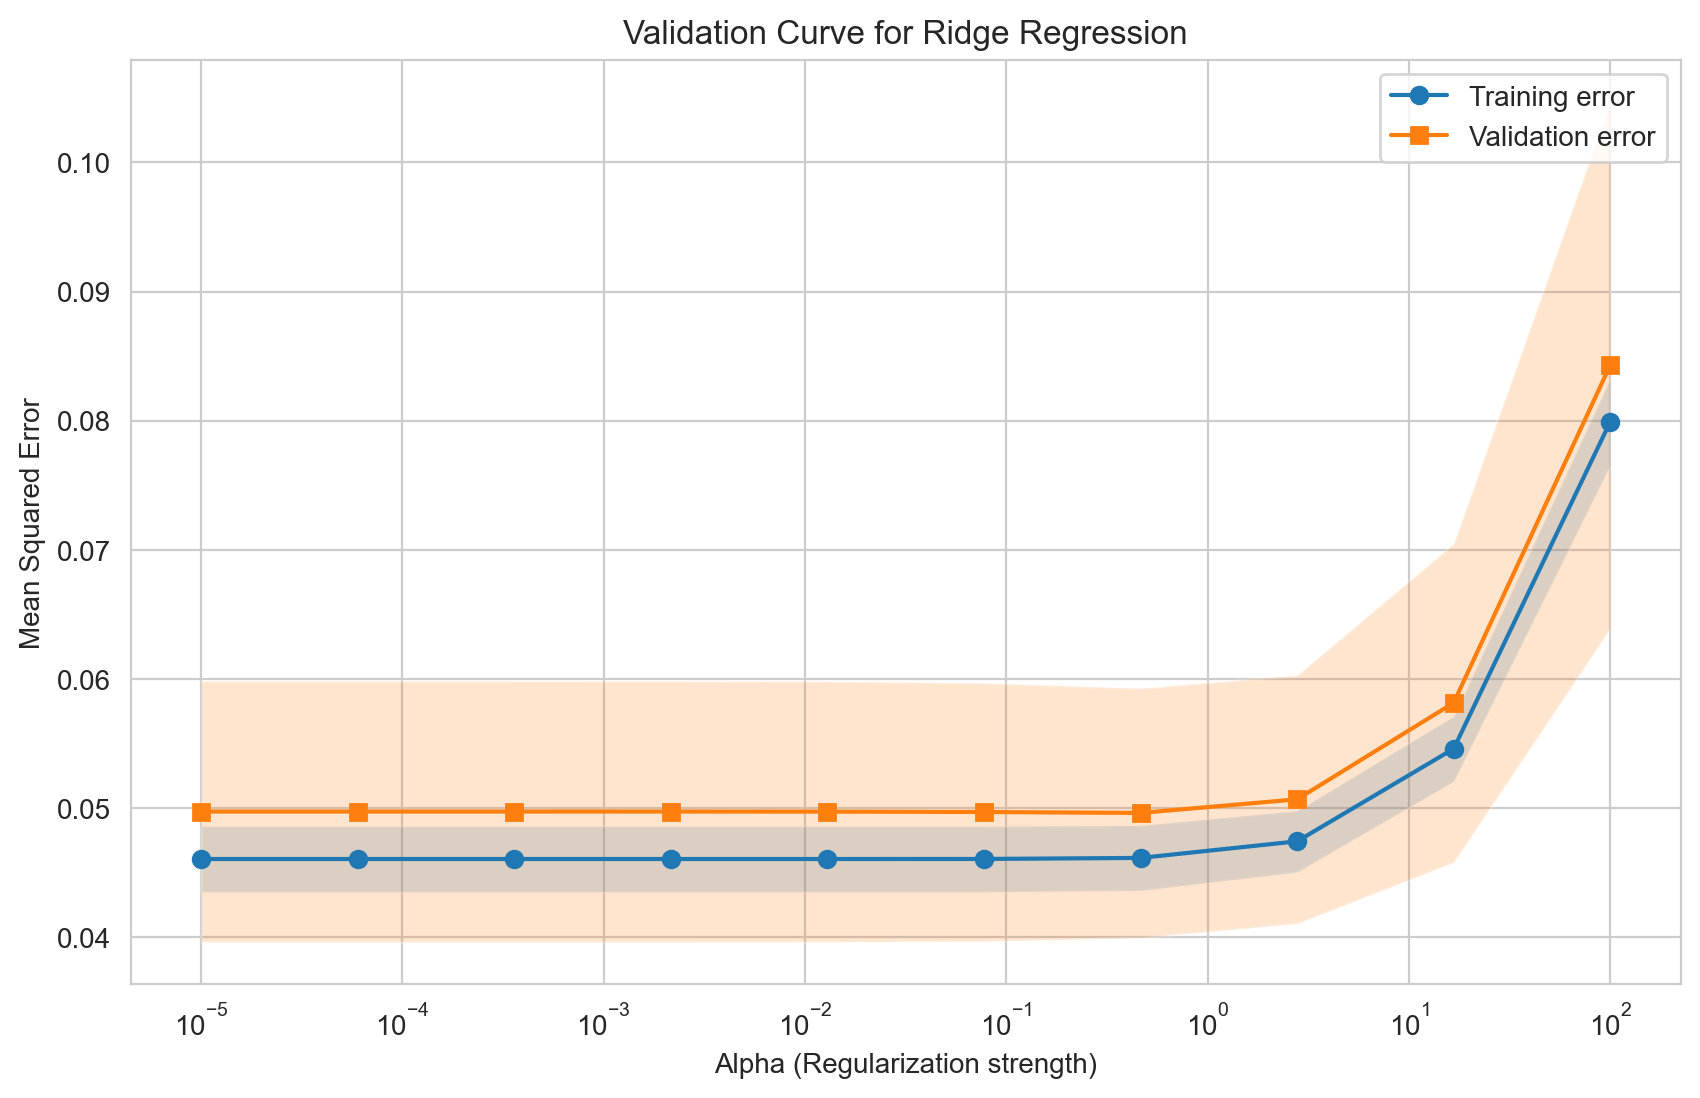

In [17]:
train_scores, valid_scores = validation_curve(
    Ridge(),
    X,
    y,
    param_name=param_name,
    param_range=param_range,
    cv=5,               # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Since it's regression
    n_jobs=-1           # Use all processors
)

# Convert negative MSE to positive MSE for better interpretation
train_errors = -train_scores
valid_errors = -valid_scores

# Calculate mean and std across folds
train_mean = train_errors.mean(axis=1)
train_std = train_errors.std(axis=1)
valid_mean = valid_errors.mean(axis=1)
valid_std = valid_errors.std(axis=1)

# Plot validation curve
plt.figure(figsize=(10,6))
plt.semilogx(param_range, train_mean, label='Training error', marker='o')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2)

plt.semilogx(param_range, valid_mean, label='Validation error', marker='s')
plt.fill_between(param_range, valid_mean - valid_std, valid_mean + valid_std, alpha=0.2)

plt.xlabel('Alpha (Regularization strength)')
plt.ylabel('Mean Squared Error')
plt.title('Validation Curve for Ridge Regression')
plt.legend()
plt.grid(True)
plt.show()

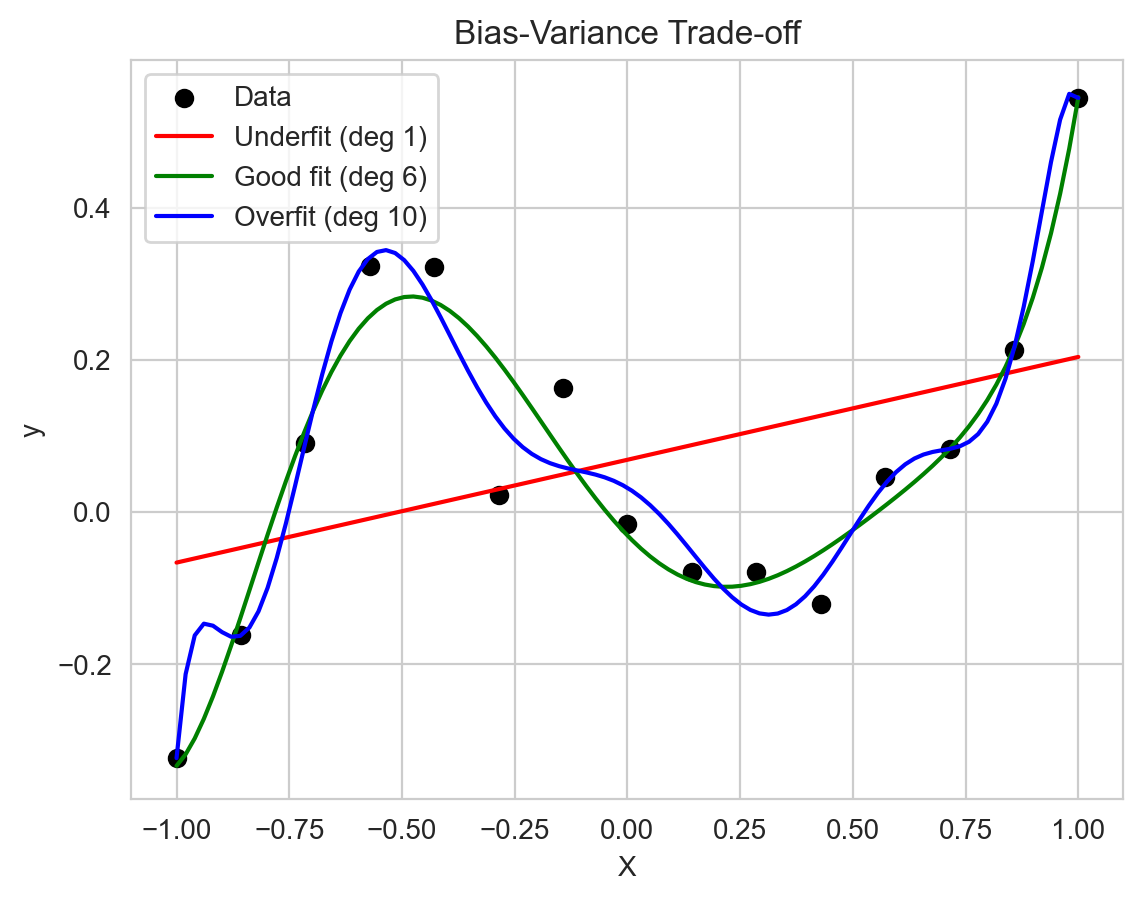

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

np.random.seed(0)
X = np.linspace(-1, 1, 15).reshape(-1, 1)
y = X**3 - 0.5*X + 0.1 * np.random.randn(15, 1)

model_under = make_pipeline(PolynomialFeatures(1), LinearRegression())
model_good  = make_pipeline(PolynomialFeatures(6), LinearRegression())
model_over  = make_pipeline(PolynomialFeatures(10), LinearRegression())

model_under.fit(X, y)
model_good.fit(X, y)
model_over.fit(X, y)

X_plot = np.linspace(-1, 1, 100).reshape(-1, 1)
y_under = model_under.predict(X_plot)
y_good  = model_good.predict(X_plot)
y_over  = model_over.predict(X_plot)


plt.scatter(X, y, color='black', label='Data')
plt.plot(X_plot, y_under, label='Underfit (deg 1)', color='red')
plt.plot(X_plot, y_good, label='Good fit (deg 6)', color='green')
plt.plot(X_plot, y_over, label='Overfit (deg 10)', color='blue')
plt.title("Bias-Variance Trade-off")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import validation_curve

# Simple synthetic data
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = np.array([1.2, 1.9, 3.1, 3.9, 5.1, 6.0, 6.9, 8.1, 8.9, 10.2])

In [19]:
param_range = np.logspace(-4, 2, 10)

In [22]:
t_score , v_score = validation_curve(
     Ridge(),
     X,y,
     param_name="alpha",
     param_range=param_range,
     scoring= 'r2',
     cv = 5)

In [23]:
t_Score_mean  = np.mean(t_score, axis= 1)
v_score_mean  = np.mean(v_score, axis =1)

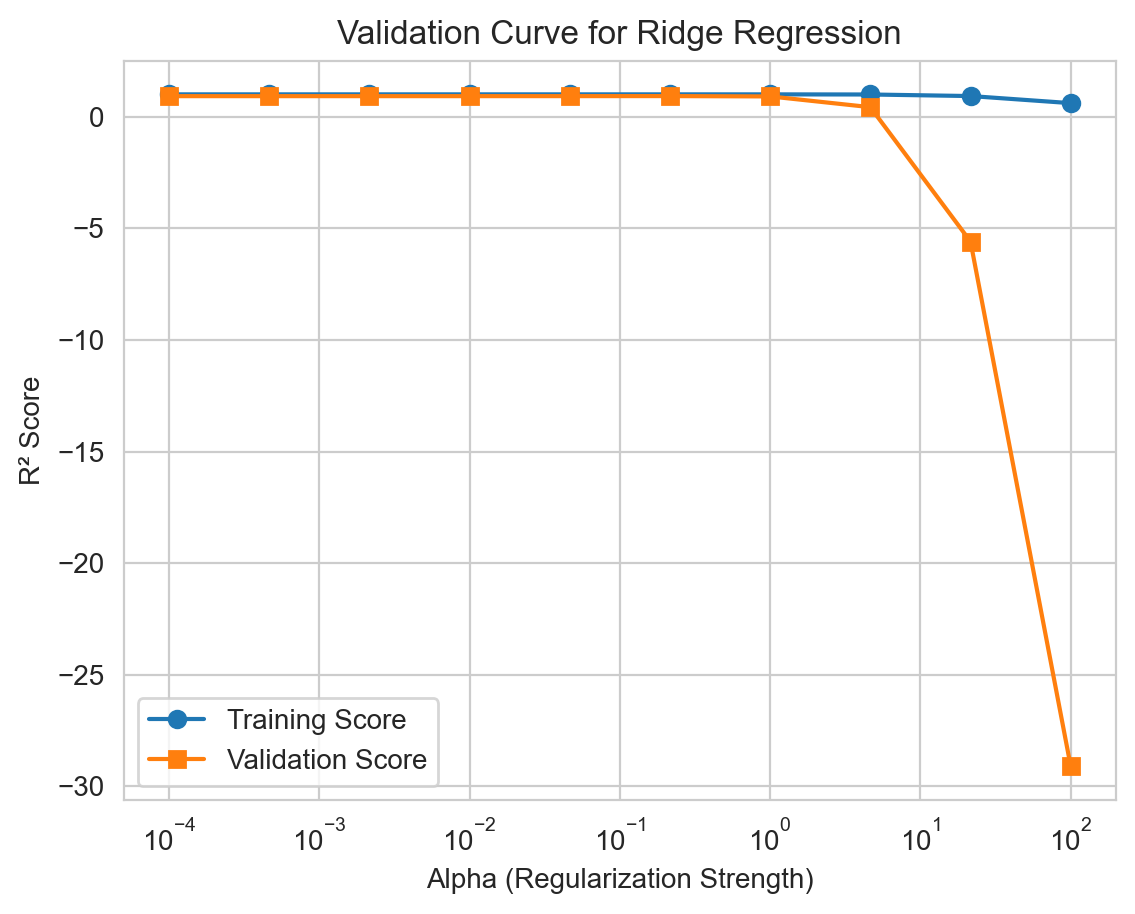

In [30]:
plt.plot(param_range, t_Score_mean, label="Training Score", marker='o')
plt.plot(param_range, v_score_mean, label="Validation Score", marker='s')
plt.xscale('log')
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("R² Score")
plt.title("Validation Curve for Ridge Regression")
plt.legend()
plt.grid(True)


#  Learning Curve

A learning curve shows how the model's performance changes with increasing training data size.

X-axis → Number of training samples

Y-axis → Performance (e.g., accuracy, R² score)

It helps detect:

Underfitting (train & val scores both low)

Overfitting (high train score, low val score)

Good fit (both scores converge)

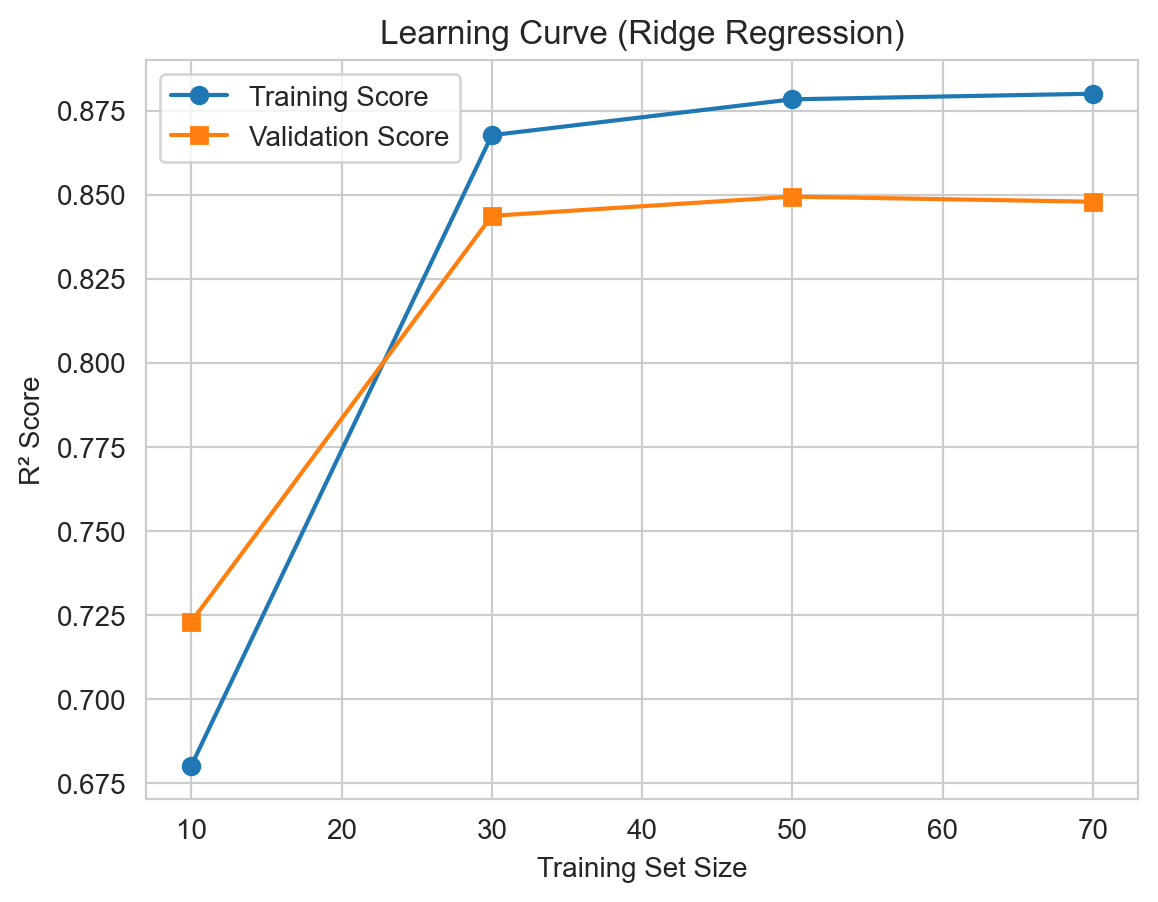

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import learning_curve
from sklearn.datasets import make_regression

# Generate synthetic regression data
X, y = make_regression(n_samples=100, n_features=1, noise=15, random_state=0)

# Get learning curve data with valid sizes
train_sizes, train_scores, val_scores = learning_curve(
    estimator=Ridge(alpha=1.0),
    X=X,
    y=y,
    train_sizes=[10, 30, 50, 70],  # max is 80 for 5-fold CV
    cv=5,
    scoring='r2'
)

# Compute mean scores across folds
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot the learning curve
plt.plot(train_sizes, train_mean, label="Training Score", marker='o')
plt.plot(train_sizes, val_mean, label="Validation Score", marker='s')
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve (Ridge Regression)")
plt.legend()
plt.grid(True)
plt.show()


In [51]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression

# Create data
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=0)

# Model
model = Ridge(alpha=1.0)

# K-Fold Cross-Validation (5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=0)

# Perform cross-validation
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print("R² scores in each fold:", scores)
print("Average R² score:", scores.mean())


R² scores in each fold: [0.9378085  0.95558157 0.87295914 0.92516966 0.95788285]
Average R² score: 0.92988034429581
